# ubaidp1049 ANPR Dataset — Inspection

**Source:** [ubaidp1049/pakistani-vehicle-number-plate-anpr-yolo](https://www.kaggle.com/datasets/ubaidp1049/pakistani-vehicle-number-plate-anpr-yolo) (Kaggle, CC0)  
**Role in project:** Augmentation dataset — merged into the baseline training pool to improve diversity.

## Why I'm inspecting this dataset

My baseline YOLOv8n hit **mAP@0.5 = 0.99 on test**, but the *validation* set showed weaker recall (0.84). That gap suggests the model misses certain plate types — likely the ones the Burhan Khan dataset under-represents.

Before merging anything, I need to answer four questions:

1. **Is it compatible?** Same YOLO format, same single-class schema?
2. **Is it different enough to matter?** If ubaidp1049's plates look statistically identical to Burhan Khan's, merging adds rows but no information.
3. **Is it labeled correctly?** A bad label is worse than no label — it actively confuses the model.
4. **Are there duplicates with Burhan Khan?** Same image in train and test = leakage = inflated metrics.

This notebook answers questions 1–3. Question 4 (deduplication) gets its own dedicated script in the next step because it needs perceptual hashing.

In [1]:
"""ubaidp1049 inspection — load this dataset and the Burhan Khan baseline
stats so I can compare them on the same axes."""

from pathlib import Path
import random
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

random.seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
UBAID_ROOT = PROJECT_ROOT / "data" / "raw" / "ubaidp1049_raw"
UBAID_IMGS = UBAID_ROOT / "images" / "images"   # double-nested in the source
UBAID_LBLS = UBAID_ROOT / "labels" / "labels"
BURHAN_ROOT = PROJECT_ROOT / "data" / "raw" / "Pk-Number-Plates-1"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

# Single class is implicit (no data.yaml in this dataset); set it explicitly
CLASS_NAMES = ["Number-Plate"]

print(f"ubaidp1049 images: {len(list(UBAID_IMGS.glob('*.jpg')))}")
print(f"ubaidp1049 labels: {len(list(UBAID_LBLS.glob('*.txt')))}")

ubaidp1049 images: 76
ubaidp1049 labels: 76


## 1. Visual sanity check

Same approach I used on Burhan Khan: pick 16 random images, overlay ground-truth boxes, look. If the boxes consistently sit on plates, the dataset is trustworthy. If they don't, I either clean it or skip it.

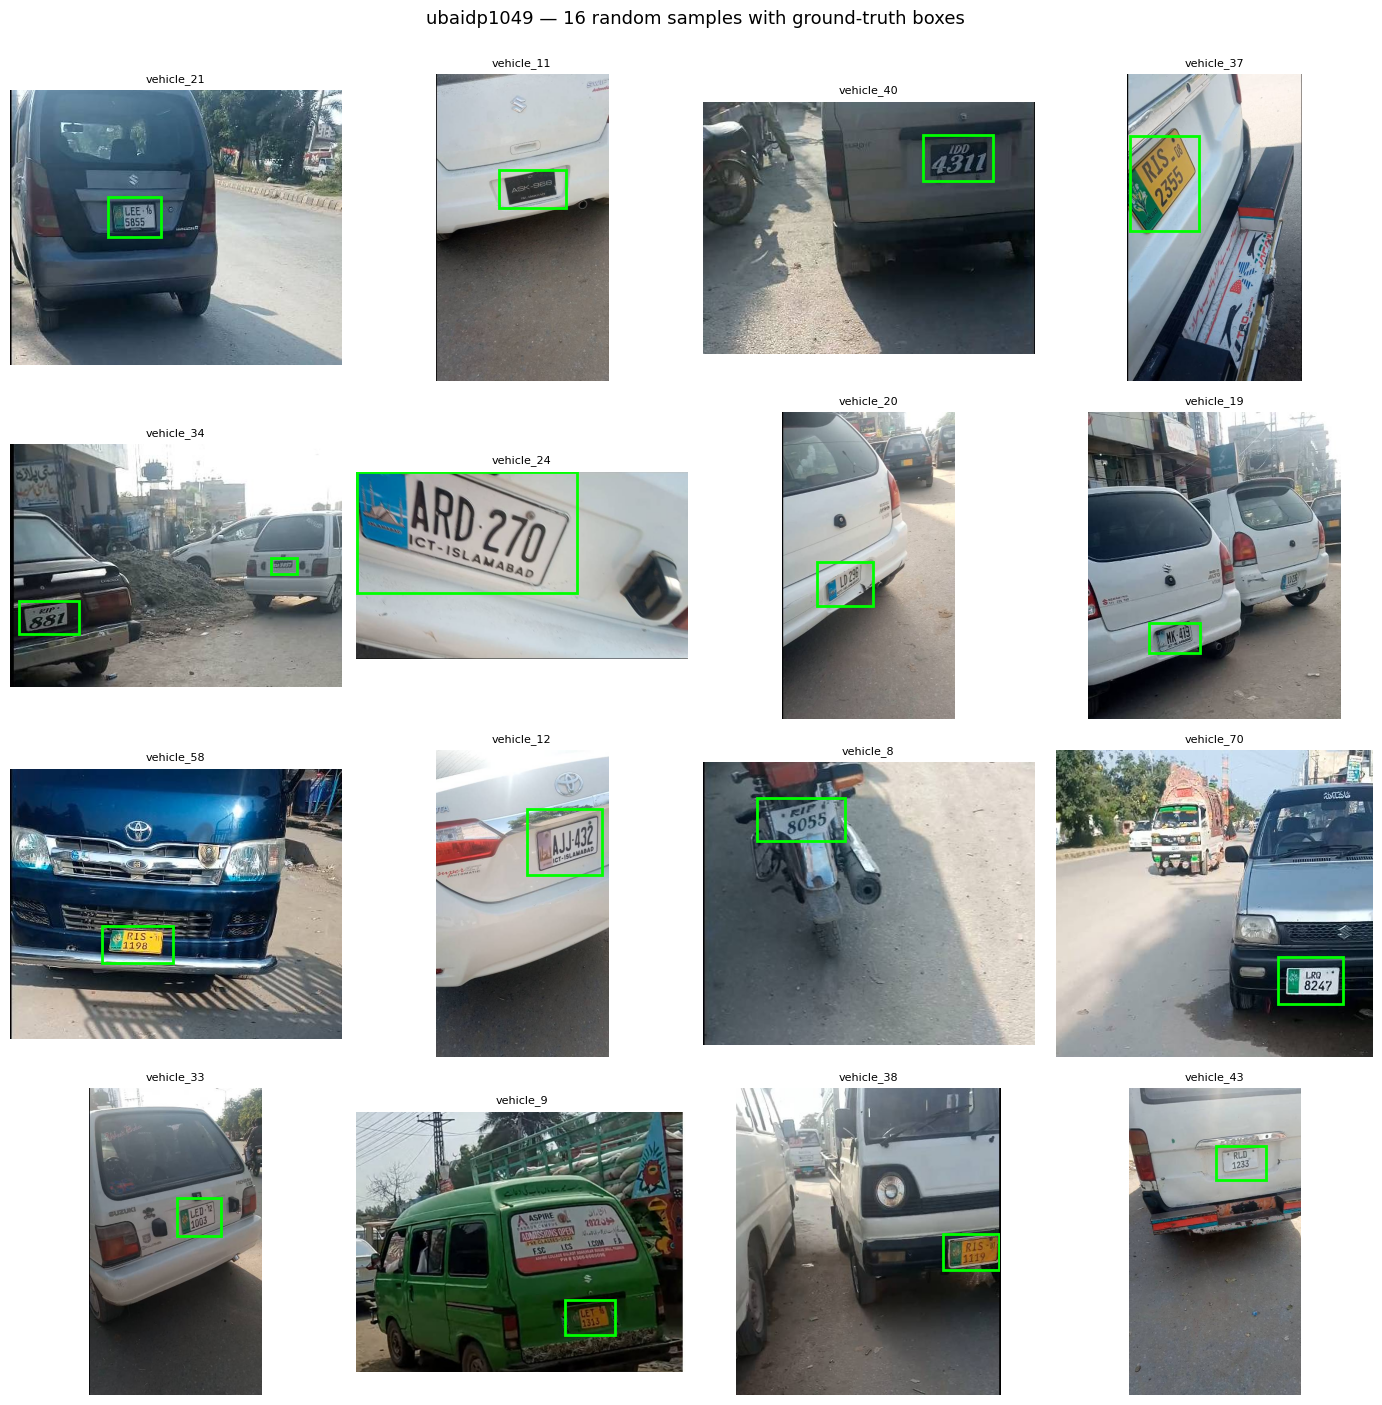

In [2]:
"""Reuse the label-drawing helpers from the previous notebook — copy-paste
inline here so this notebook stands alone."""

def load_yolo_labels(label_path: Path):
    if not label_path.exists():
        return []
    rows = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            rows.append((int(parts[0]), *map(float, parts[1:])))
    return rows


def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    return ((xc - w/2) * img_w, (yc - h/2) * img_h,
            (xc + w/2) * img_w, (yc + h/2) * img_h)


def show_image_with_boxes(img_path: Path, ax, label_dir: Path):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.stem[:25], fontsize=8)
    for cls, xc, yc, w, h in load_yolo_labels(label_dir / f"{img_path.stem}.txt"):
        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, img.width, img.height)
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)


imgs = sorted(UBAID_IMGS.glob("*.jpg"))
sample = random.sample(imgs, 16)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, img_path in zip(axes.flat, sample):
    show_image_with_boxes(img_path, ax, UBAID_LBLS)

fig.suptitle("ubaidp1049 — 16 random samples with ground-truth boxes", fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_ubaidp1049_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Distribution comparison — does this dataset add new information?

Now the important check. I'll compute the same bounding-box statistics for ubaidp1049 that I computed for Burhan Khan, then plot them on shared axes. If the two distributions overlap perfectly, the merge is a waste of compute. If they differ meaningfully — especially in box size or aspect ratio — the merge adds real diversity.

**What I expect from the label samples I already saw:** ubaidp1049's plates are larger in the frame than Burhan Khan's. That would mean ubaidp1049 covers the *close-up* plate regime that Burhan Khan under-samples.

In [3]:
"""Build one DataFrame per dataset, then concat for plotting."""

def collect_box_stats(img_dir: Path, lbl_dir: Path, dataset_name: str) -> pd.DataFrame:
    rows = []
    for img in img_dir.glob("*.jpg"):
        for cls, xc, yc, w, h in load_yolo_labels(lbl_dir / f"{img.stem}.txt"):
            rows.append({"dataset": dataset_name, "xc": xc, "yc": yc,
                         "w": w, "h": h, "area": w*h, "ar": w/h if h > 0 else 0})
    return pd.DataFrame(rows)


ubaid_df = collect_box_stats(UBAID_IMGS, UBAID_LBLS, "ubaidp1049")

# Burhan Khan: walk all three splits
burhan_dfs = []
for split in ["train", "valid", "test"]:
    burhan_dfs.append(collect_box_stats(
        BURHAN_ROOT / split / "images",
        BURHAN_ROOT / split / "labels",
        "burhan_khan",
    ))
burhan_df = pd.concat(burhan_dfs, ignore_index=True)

combined = pd.concat([burhan_df, ubaid_df], ignore_index=True)

print("=== ubaidp1049 ===")
print(ubaid_df[["w", "h", "area", "ar"]].describe().round(3))
print("\n=== burhan_khan ===")
print(burhan_df[["w", "h", "area", "ar"]].describe().round(3))
print(f"\nubaid total boxes: {len(ubaid_df)}")
print(f"burhan total boxes: {len(burhan_df)}")

=== ubaidp1049 ===
            w       h    area      ar
count  79.000  79.000  79.000  79.000
mean    0.269   0.181   0.054   1.608
std     0.122   0.087   0.056   0.637
min     0.080   0.066   0.005   0.316
25%     0.200   0.132   0.028   1.192
50%     0.227   0.161   0.036   1.459
75%     0.327   0.205   0.058   2.042
max     0.665   0.646   0.430   3.531

=== burhan_khan ===
              w         h      area        ar
count  1443.000  1443.000  1443.000  1443.000
mean      0.130     0.084     0.012     1.648
std       0.068     0.037     0.008     0.679
min       0.006     0.006     0.000     0.397
25%       0.090     0.067     0.008     1.054
50%       0.124     0.094     0.012     1.625
75%       0.183     0.109     0.017     2.054
max       0.389     0.179     0.046     5.931

ubaid total boxes: 79
burhan total boxes: 1443


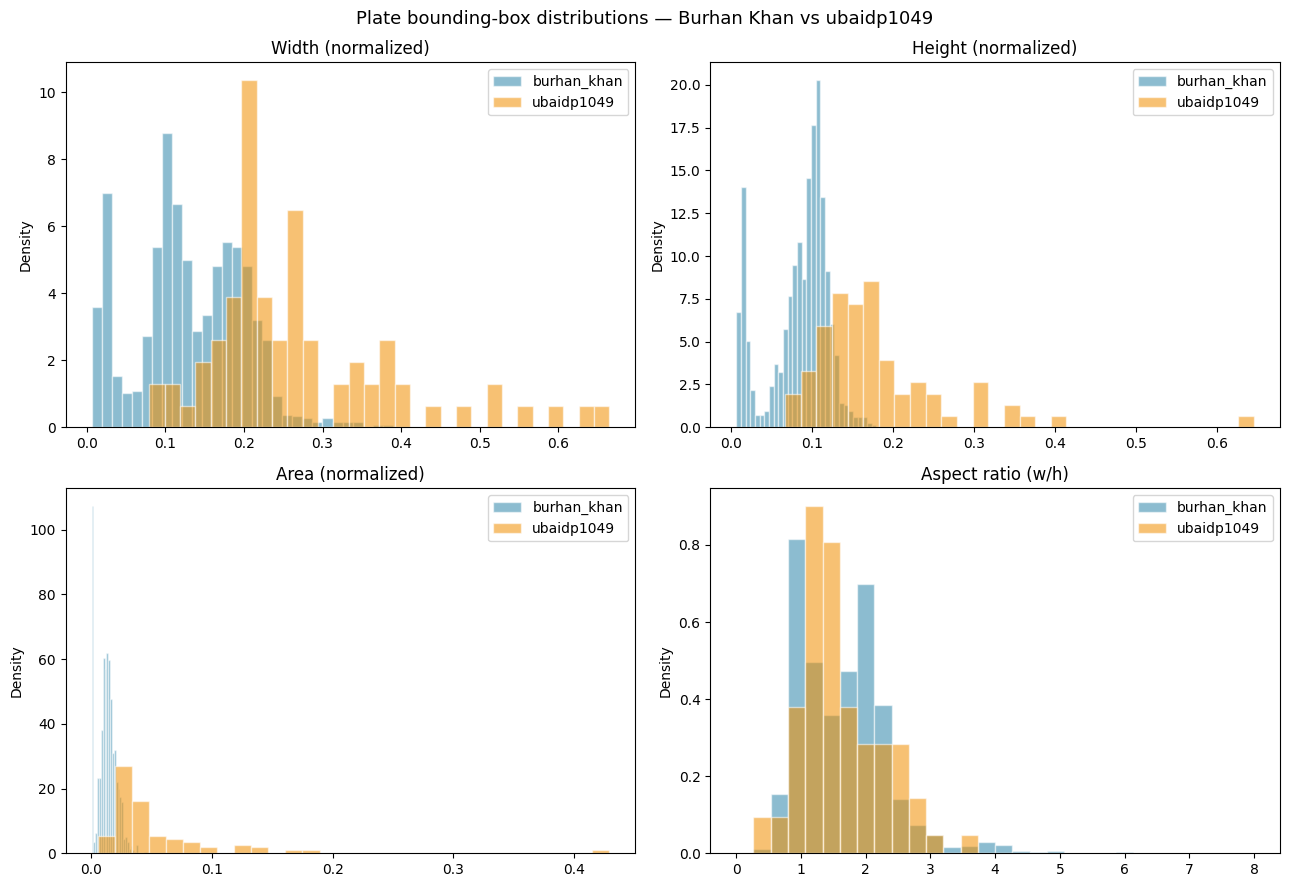

Median plate area:
  burhan_khan: 0.0125
  ubaidp1049:  0.0358
  ratio (ubaid / burhan): 2.87x


In [4]:
"""Side-by-side histograms — width, height, area, aspect ratio.
This single figure is the empirical justification for the merge."""

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {"burhan_khan": "#2E86AB", "ubaidp1049": "#F18F01"}

for ax, col, title in zip(
    axes.flat,
    ["w", "h", "area", "ar"],
    ["Width (normalized)", "Height (normalized)", "Area (normalized)", "Aspect ratio (w/h)"],
):
    for ds, color in colors.items():
        data = combined.loc[combined["dataset"] == ds, col]
        ax.hist(data, bins=30, alpha=0.55, label=ds, color=color, edgecolor="white",
                range=(0, 8) if col == "ar" else None, density=True)
    ax.set_title(title)
    ax.legend()
    ax.set_ylabel("Density")

fig.suptitle("Plate bounding-box distributions — Burhan Khan vs ubaidp1049", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_dataset_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Quick numeric summary for the report
print(f"Median plate area:")
print(f"  burhan_khan: {burhan_df['area'].median():.4f}")
print(f"  ubaidp1049:  {ubaid_df['area'].median():.4f}")
print(f"  ratio (ubaid / burhan): {ubaid_df['area'].median() / burhan_df['area'].median():.2f}x")

## 3. Decision

Fill this in after running the cells above:

- **Label quality:** _(eyeball test verdict)_
- **Box size difference:** _(from the area histogram and ratio number)_
- **Aspect ratio difference:** _(from the AR histogram)_
- **Verdict:** Proceed with merge / Skip merge / Need to clean first.